In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
import warnings
from csv import reader
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2563a8', '#e05c1a', '#16a34a', '#dc2626', '#7c3aed', '#0891b2']

## Loading The Data

The dataset contains transactional data where each row represents a customer's purchase —with a variable number of items per transaction (ragged structure).

Unlike structured datasets with fixed columns,this cannot be directly loaded using pd.read_csv().

Instead, Python's built-in csv.reader() is usedto parse each row as a separate list, resulting in a list of lists — where each inner list represents one transaction.

This format is the required input for TransactionEncoder in the next step.

In [3]:
groceries = []
with open('groceries.csv', 'r') as f:
    for row in reader(f):
        groceries.append(row)

In [4]:
print(f' Total Transactions   : {len(groceries):,}')
print(f' Unique Items         : {len(set(item for txn in groceries for item in txn))}')
print(f' Total Items Purchased: {sum(len(t) for t in groceries):,}')
print(f' Avg Items per Basket : {sum(len(t) for t in groceries)/len(groceries):.2f}')
print(f' Max Items in 1 Basket: {max(len(t) for t in groceries)}')
print(f' Min Items in 1 Basket: {min(len(t) for t in groceries)}')

 Total Transactions   : 9,835
 Unique Items         : 169
 Total Items Purchased: 43,367
 Avg Items per Basket : 4.41
 Max Items in 1 Basket: 32
 Min Items in 1 Basket: 1


In [5]:
for i, txn in enumerate(groceries[:5]):
    print(f'Transaction {i+1}: {txn}')

Transaction 1: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
Transaction 2: ['tropical fruit', 'yogurt', 'coffee']
Transaction 3: ['whole milk']
Transaction 4: ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads']
Transaction 5: ['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']


# Exploratory Data Analysis(EDA)

In [6]:
#  Basket Size Distribution 
basket_sizes = [len(t) for t in groceries]
size_counts = Counter(basket_sizes)

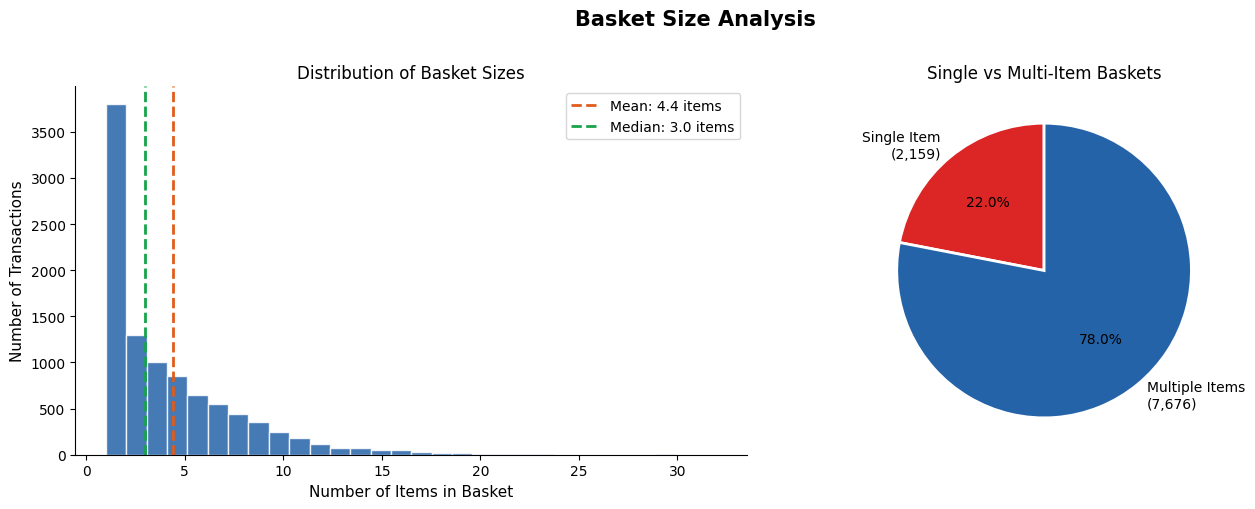

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Basket Size Analysis', fontsize=15, fontweight='bold', y=1.01)

# Histogram
axes[0].hist(basket_sizes, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(basket_sizes), color=PALETTE[1], linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(basket_sizes):.1f} items')
axes[0].axvline(np.median(basket_sizes), color=PALETTE[2], linestyle='--', linewidth=2,
                label=f'Median: {np.median(basket_sizes):.1f} items')
axes[0].set_xlabel('Number of Items in Basket', fontsize=11)
axes[0].set_ylabel('Number of Transactions', fontsize=11)
axes[0].set_title('Distribution of Basket Sizes', fontsize=12)
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Pie — single vs multi item
single = sum(1 for s in basket_sizes if s == 1)
multi  = len(basket_sizes) - single
axes[1].pie([single, multi],
            labels=[f'Single Item\n({single:,})', f'Multiple Items\n({multi:,})'],
            colors=[PALETTE[3], PALETTE[0]], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Single vs Multi-Item Baskets', fontsize=12)

plt.tight_layout()
plt.savefig('basket_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Mean(Average) :- 4.4 item per Basket 
Median :- 50% customer take less than 3 items or 50% customer take greater than 3 item .
The median is giving us more accurate information because some customers are purchasing 14, 15, or even 20 items, which is pulling the mean upward.

Insight: Most customers buy 1-5 items per visit. Upselling strategies should target single-item buyers

In [8]:
#  Top 20 Most Popular Products 
all_items = [item for txn in groceries for item in txn]


In [9]:
# Count All the items
item_counts = Counter(all_items)
item_counts

Counter({'whole milk': 2513,
         'other vegetables': 1903,
         'rolls/buns': 1809,
         'soda': 1715,
         'yogurt': 1372,
         'bottled water': 1087,
         'root vegetables': 1072,
         'tropical fruit': 1032,
         'shopping bags': 969,
         'sausage': 924,
         'pastry': 875,
         'citrus fruit': 814,
         'bottled beer': 792,
         'newspapers': 785,
         'canned beer': 764,
         'pip fruit': 744,
         'fruit/vegetable juice': 711,
         'whipped/sour cream': 705,
         'brown bread': 638,
         'domestic eggs': 624,
         'frankfurter': 580,
         'margarine': 576,
         'coffee': 571,
         'pork': 567,
         'butter': 545,
         'curd': 524,
         'beef': 516,
         'napkins': 515,
         'chocolate': 488,
         'frozen vegetables': 473,
         'chicken': 422,
         'white bread': 414,
         'cream cheese ': 390,
         'waffles': 378,
         'salty snack': 372,
     

In [10]:
# Extract top20 items
top20 = pd.DataFrame(item_counts.most_common(20), columns=['Item', 'Count'])
top20

,Item,Count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372
5,bottled water,1087
6,root vegetables,1072
7,tropical fruit,1032
8,shopping bags,969
9,sausage,924


In [11]:
top20['Frequency_%'] = (top20['Count'] / len(groceries) * 100).round(2)

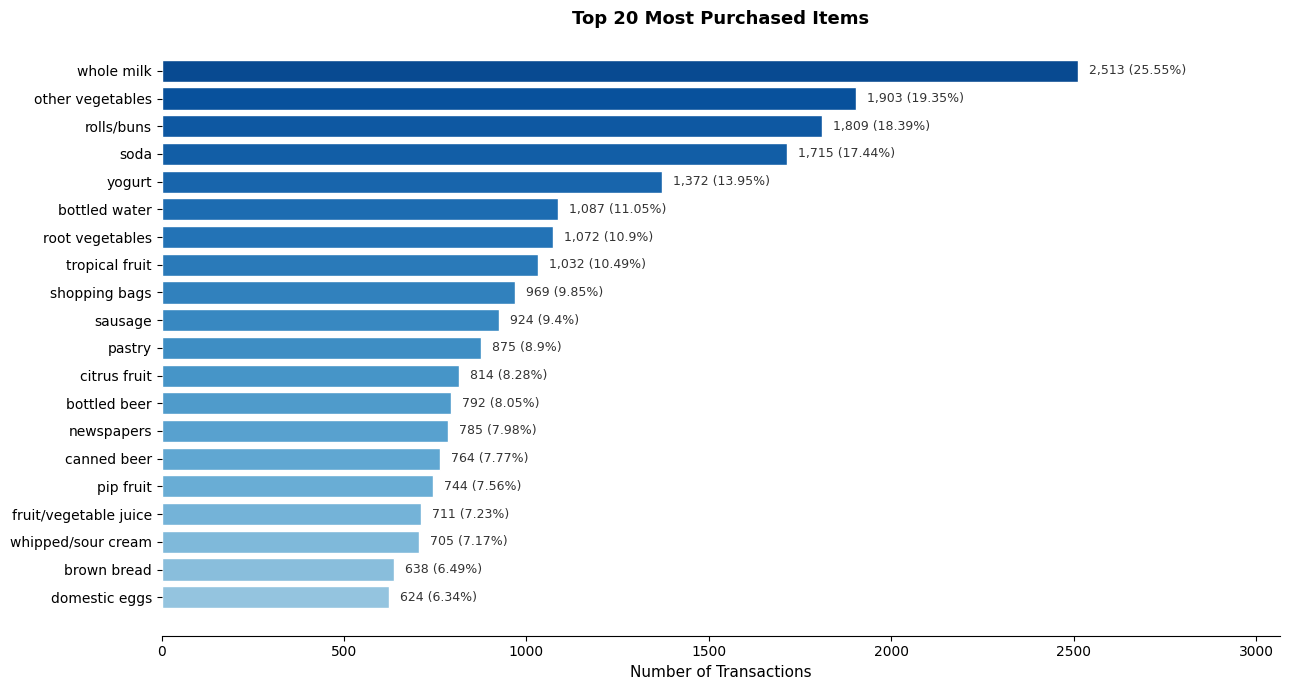

In [12]:
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top20['Item'][::-1], 
    top20['Count'][::-1],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, 20)), 
    edgecolor='white'
)

# Simple label loop
for i, (count, freq) in enumerate(zip(top20['Count'][::-1], top20['Frequency_%'][::-1])):
    ax.text(count + 30, i, 
            f"{count:,} ({freq}%)",
            va='center', fontsize=9, color='#333')

ax.set_xlabel('Number of Transactions', fontsize=11)
ax.set_title('Top 20 Most Purchased Items', fontsize=13, fontweight='bold')
ax.spines[['top','right','left']].set_visible(False)
ax.set_xlim(0, top20['Count'].max() * 1.22)
plt.tight_layout()
plt.show()



 Insight:- 'Whole Milk' appears in 25.55% of all transactions.
 This is the most critical anchor product for bundle and promotion strategies.

In [13]:
# Category-Level Analysis
# Manually mapping items to business categories
category_map = {
    'Dairy'        : ['whole milk', 'yogurt', 'butter', 'butter milk', 'UHT-milk',
                      'whipped/sour cream', 'curd', 'curd cheese', 'domestic eggs',
                      'cream cheese ', 'hard cheese', 'sliced cheese', 'soft cheese',
                      'spread cheese', 'specialty cheese', 'processed cheese',
                      'condensed milk', 'cream', 'ice cream'],

    'Produce'      : ['other vegetables', 'tropical fruit', 'root vegetables',
                      'citrus fruit', 'pip fruit', 'fruit/vegetable juice',
                      'frozen vegetables', 'berries', 'grapes', 'onions',
                      'herbs', 'pickled vegetables', 'canned vegetables',
                      'canned fruit', 'packaged fruit/vegetables',
                      'specialty vegetables', 'frozen fruits'],

    'Bakery'       : ['rolls/buns', 'brown bread', 'white bread', 'semi-finished bread',
                      'pastry', 'waffles', 'baking powder', 'flour',
                      'cake bar', 'roll products ', 'zwieback'],

    'Beverages'    : ['soda', 'bottled water', 'coffee', 'instant coffee', 'tea',
                      'bottled beer', 'canned beer', 'red/blush wine', 'white wine',
                      'sparkling wine', 'prosecco', 'brandy', 'rum', 'whisky',
                      'liquor', 'liquor (appetizer)', 'liqueur',
                      'cocoa drinks', 'beverages', 'misc. beverages'],

    'Meat'         : ['beef', 'chicken', 'pork', 'sausage', 'organic sausage',
                      'ham', 'turkey', 'frankfurter', 'hamburger meat',
                      'meat', 'meat spreads', 'liver loaf',
                      'fish', 'canned fish', 'frozen fish', 'frozen chicken'],

    'Snacks'       : ['chocolate', 'specialty chocolate', 'cooking chocolate',
                      'chocolate marshmallow', 'specialty bar', 'salty snack',
                      'candy', 'chewing gum', 'popcorn', 'nut snack',
                      'nuts/prunes', 'tidbits', 'snack products'],

    'Frozen'       : ['frozen meals', 'frozen dessert', 'frozen potato products'],

    'Household'    : ['shopping bags', 'napkins', 'detergent', 'softener',
                      'dish cleaner', 'bathroom cleaner', 'abrasive cleaner',
                      'cleaner', 'toilet cleaner', 'soap', 'rubbing alcohol',
                      'candles', 'light bulbs', 'kitchen towels', 'dishes',
                      'cling film/bags', 'bags', 'kitchen utensil',
                      'house keeping products', 'decalcifier'],

    'Personal Care': ['hygiene articles', 'dental care', 'skin care', 'hair spray',
                      'male cosmetics', 'baby cosmetics', 'baby food',
                      'female sanitary products', 'make up remover', 'photo/film'],

    'Other'        : ['margarine', 'sugar', 'oil', 'salt', 'honey', 'jam',
                      'ketchup', 'mustard', 'vinegar', 'sauces', 'mayonnaise',
                      'salad dressing', 'spices', 'syrup', 'sweet spreads',
                      'pasta', 'rice', 'cereals', 'dessert', 'pudding powder',
                      'artif. sweetener', 'specialty fat', 'long life bakery product',
                      'Instant food products', 'finished products', 'ready soups',
                      'soups', 'frozen meals',
                      'cat food', 'dog food', 'pet care',
                      'newspapers', 'pot plants', 'flower (seeds)',
                      'flower soil/fertilizer', 'cookware', 'seasonal products',
                      'organic products', 'specialty vegetables',
                      'sound storage medium', 'preservation products'],
}

In [14]:
# Count Products in category
cat_counts = {}
for cat, items in category_map.items():
    cat_counts[cat] = sum(item_counts[i] for i in items)


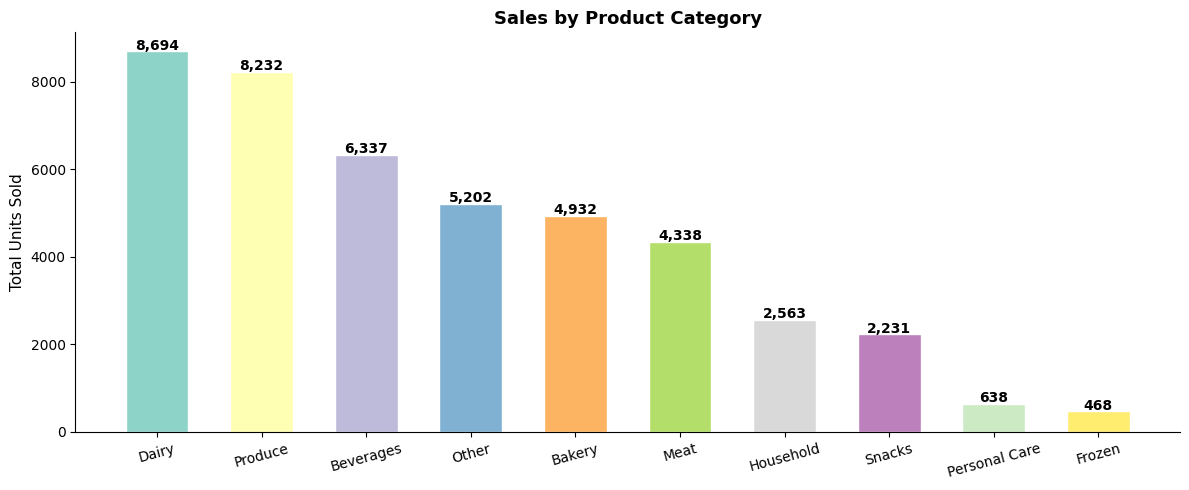

Insight: Dairy & Produce dominate sales — prime candidates for cross-sell bundling.


In [15]:
cat_df = pd.DataFrame(
    list(cat_counts.items()), 
    columns=['Category', 'Count']
).sort_values('Count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cat_df['Category'], cat_df['Count'],
       color=plt.cm.Set3(np.linspace(0, 1, len(cat_df))),
       edgecolor='white', width=0.6)

for i, (_, row) in enumerate(cat_df.iterrows()):
    ax.text(i, row['Count'] + 40, 
            f"{row['Count']:,}", 
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Total Units Sold', fontsize=11)
ax.set_title('Sales by Product Category', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Insight: Dairy & Produce dominate sales — prime candidates for cross-sell bundling.')

## Data Preprocessing & Apriori Algorithm

In [16]:
# Encode transactions
encoder = TransactionEncoder()
te_array = encoder.fit_transform(groceries)
df = pd.DataFrame(te_array, columns=encoder.columns_)

print(f' Transaction Matrix Shape: {df.shape}')
print(f'  Rows = Transactions | Columns = Unique Items')
print(f'  Sparsity: {(1 - df.values.sum()/(df.shape[0]*df.shape[1]))*100:.1f}% zeros (very sparse — normal for basket data)')

 Transaction Matrix Shape: (9835, 169)
  Rows = Transactions | Columns = Unique Items
  Sparsity: 97.4% zeros (very sparse — normal for basket data)


In [17]:
# Apriori Algo
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)


In [18]:
print('Frequent Itemsets Summary:')
print(f"  1-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==1])}")
print(f"  2-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==2])}")
print(f"  3-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==3])}")
print(f"  Total      : {len(frequent_itemsets)}")


Frequent Itemsets Summary:
  1-itemsets : 88
  2-itemsets : 213
  3-itemsets : 32
  Total      : 333


In [19]:
# Generate rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f' Total Association Rules Generated: {len(rules)}')
print(f' High-confidence rules (conf > 0.4): {len(rules[rules["confidence"] > 0.4])}')
print(f' High-lift rules (lift > 2.0)      : {len(rules[rules["lift"] > 2.0])}')

 Total Association Rules Generated: 598
 High-confidence rules (conf > 0.4): 62
 High-lift rules (lift > 2.0)      : 160


## Deep Rule Analysis & Visualizations

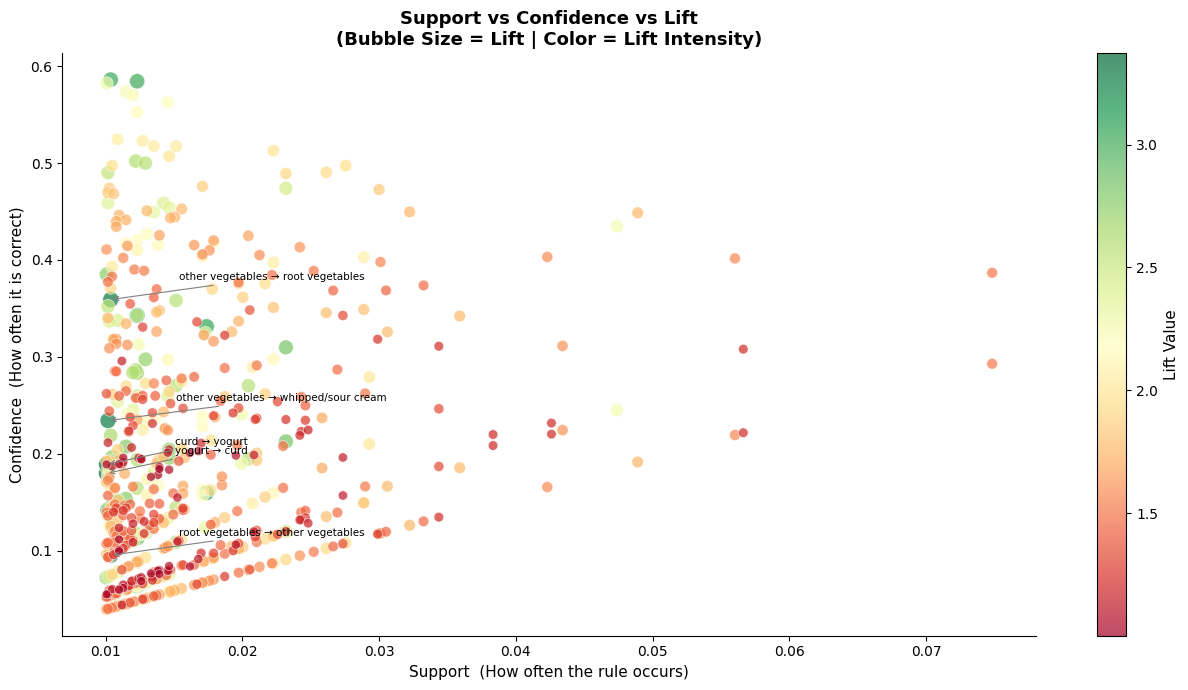

 Rules in top-right green zone = HIGH support + HIGH confidence = Best candidates for promotions


In [20]:
# Support vs Confidence vs Lift 
fig, ax = plt.subplots(figsize=(13, 7))

scatter = ax.scatter(
    rules['support'],    # X-axis
    rules['confidence'], # Y axis
    c=rules['lift'],     # color
    s=rules['lift'] * 40, #Size
    cmap='RdYlGn',        # Color scheme
    alpha=0.7,           # Transparency
    edgecolors='white',  # Dot border
    linewidth=0.5        # Border size
)
cbar = plt.colorbar(scatter)
cbar.set_label('Lift Value', fontsize=11)

# Annotate top 5 rules by lift
top5 = rules.head(5)
for _, row in top5.iterrows():
    label = f"{list(row['antecedents'])[0]} → {list(row['consequents'])[0]}"
    ax.annotate(label, (row['support'], row['confidence']),
                fontsize=7.5, ha='left',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                xytext=(row['support']+0.005, row['confidence']+0.02))

ax.set_xlabel('Support  (How often the rule occurs)', fontsize=11)
ax.set_ylabel('Confidence  (How often it is correct)', fontsize=11)
ax.set_title('Support vs Confidence vs Lift\n(Bubble Size = Lift | Color = Lift Intensity)', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('support_confidence_lift.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Rules in top-right green zone = HIGH support + HIGH confidence = Best candidates for promotions')


# Business Insights — Support vs Confidence vs Lift Scatter Plot

1. Curd - Yogurt is the Strongest Association Rule
   Both "curd - yogurt" and "yogurt - curd" appear as
   large green dots in the top-left of the graph.
   This means these two dairy products have the highest
   lift (3.0+) and are strongly purchased together.

   - Action: Place curd and yogurt together on shelves
   - Create a "Dairy Combo" bundle offer

3. Other Vegetables - Root Vegetables has Highest Confidence
   This rule appears at the top of the graph with
   confidence above 0.35 — meaning customers who buy
   other vegetables almost always buy root vegetables too.

    - Action: Display both together in the vegetable section
    - Offer a "Fresh Vegetable Bundle" discount

5. Other Vegetables - Whipped/Sour Cream is an Unexpected Rule
   Customers buying vegetables are also buying cream —
   likely for cooking purposes.
   This is a hidden cross-category opportunity.
    - Action: Place cream products near the vegetable section
    - Promote "Cooking Combo" offers

6. Most Rules are Concentrated in Low Support Zone (0.01-0.03)
   Over 90% of dots are on the left side of the graph —
   meaning most product combinations appear in less than
   3% of transactions. The top-right corner is completely empty.
    - Action: These are untapped opportunities
    - Targeted promotions can increase these combinations

7. Majority of Rules have Low to Medium Lift (Red/Yellow dots)
   Most dots in the graph are red or yellow —
   meaning most rules have lift between 1.0 and 2.0.
   Very few rules have lift above 3.0 (green dots).
    - Action: Focus promotions only on green dot rules
    - These give the highest return on investment

8. High Support Rules have Low Confidence (Right Side dots)
   Dots on the right side show high support but
   low confidence and red/yellow color —
   meaning common items like whole milk are bought
   frequently but not strongly linked to any specific product.
    - Action: Use whole milk as an anchor product
    - Place high margin items in the milk section
    - Offer "Milk + Yogurt = 10% off" type promotions

In [21]:
# Top 15 Rules by Lift 
top15 = rules.head(15).copy()
top15['rule'] = top15.apply(
    lambda r: f"{', '.join(list(r['antecedents']))}  →  {', '.join(list(r['consequents']))}", axis=1
)

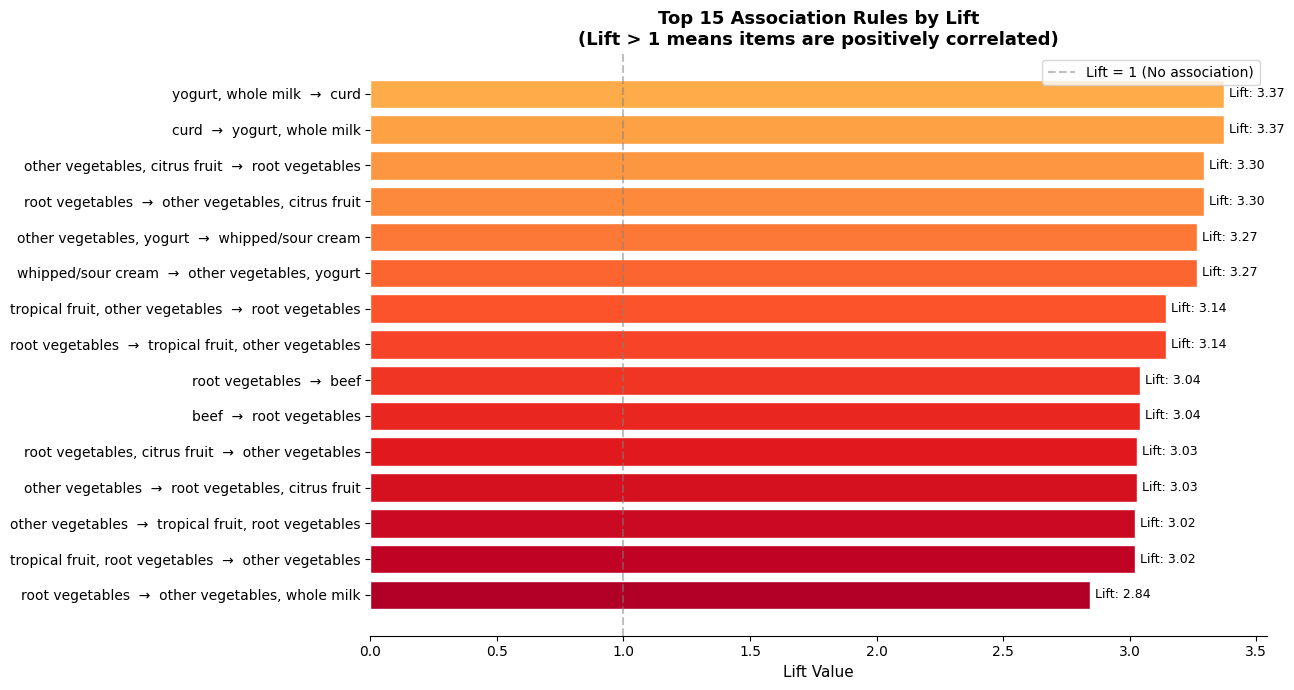

In [22]:
fig, ax = plt.subplots(figsize=(13, 7))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 15))
bars = ax.barh(top15['rule'][::-1], top15['lift'][::-1], color=colors[::-1], edgecolor='white')

for bar, lift in zip(bars, top15['lift'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'Lift: {lift:.2f}', va='center', fontsize=9)

ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='Lift = 1 (No association)')
ax.set_xlabel('Lift Value', fontsize=11)
ax.set_title('Top 15 Association Rules by Lift\n(Lift > 1 means items are positively correlated)', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.savefig('top15_rules_lift.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Top 15 Rules Table
top15_table = rules[['antecedents', 'consequents', 
                      'support', 'confidence', 
                      'lift']].head(15).copy()


top15_table['antecedents'] = top15_table['antecedents'].apply(lambda x: ', '.join(list(x)))
top15_table['consequents'] = top15_table['consequents'].apply(lambda x: ', '.join(list(x)))
top15_table['support']     = top15_table['support'].round(3)
top15_table['confidence']  = top15_table['confidence'].round(3)
top15_table['lift']        = top15_table['lift'].round(2)


top15_table.index = range(1, 16)

print(top15_table.to_string())

                         antecedents                       consequents  support  confidence  lift
1                 yogurt, whole milk                              curd    0.010       0.180  3.37
2                               curd                yogurt, whole milk    0.010       0.189  3.37
3     other vegetables, citrus fruit                   root vegetables    0.010       0.359  3.30
4                    root vegetables    other vegetables, citrus fruit    0.010       0.095  3.30
5           other vegetables, yogurt                whipped/sour cream    0.010       0.234  3.27
6                 whipped/sour cream          other vegetables, yogurt    0.010       0.142  3.27
7   tropical fruit, other vegetables                   root vegetables    0.012       0.343  3.14
8                    root vegetables  tropical fruit, other vegetables    0.012       0.113  3.14
9                    root vegetables                              beef    0.017       0.160  3.04
10                  

In [24]:
# lift Heatmap - Top Items
top_items = [i for i, _ in item_counts.most_common(12)]
lift_matrix = pd.DataFrame(np.nan, index=top_items, columns=top_items)


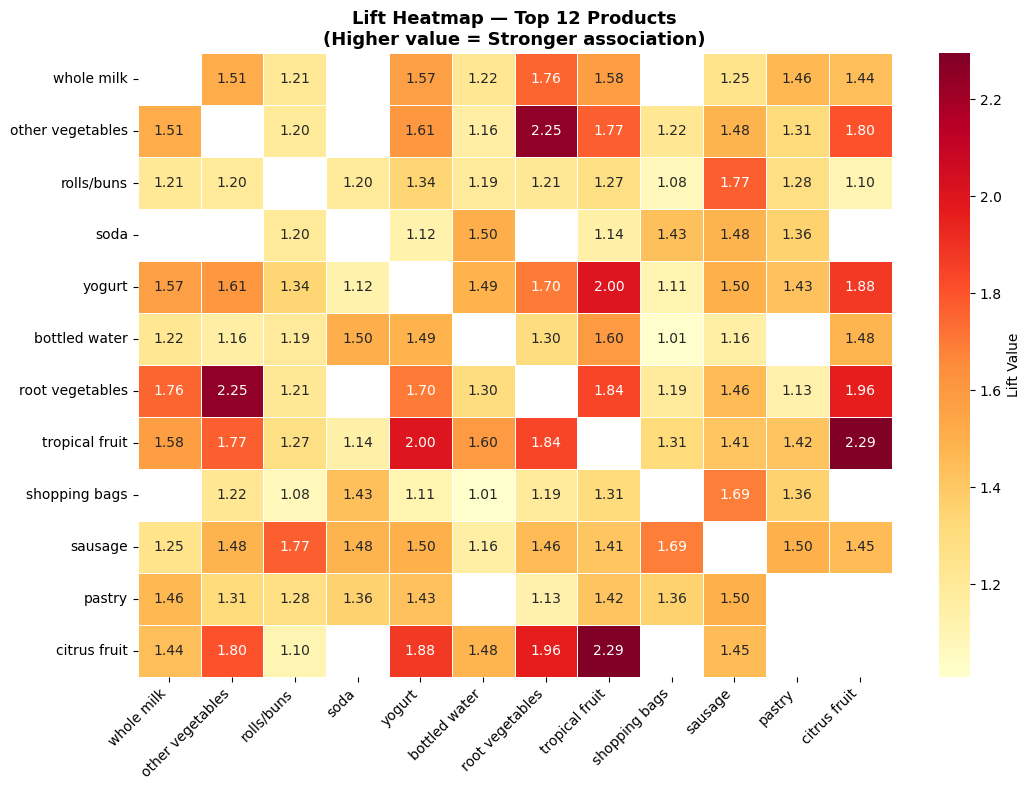

 Darker cells = stronger product pairing. Use this for shelf placement decisions.


In [25]:
for _, row in rules.iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    if len(ant) == 1 and len(con) == 1:
        a, c = ant[0], con[0]
        if a in top_items and c in top_items:
            lift_matrix.loc[a, c] = row['lift']

fig, ax = plt.subplots(figsize=(11, 8))
mask = lift_matrix.isnull()
sns.heatmap(lift_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Lift Value'})
ax.set_title('Lift Heatmap — Top 12 Products\n(Higher value = Stronger association)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('lift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Darker cells = stronger product pairing. Use this for shelf placement decisions.')

In [26]:
# Network Graph - Product Association Wed
# Filter String Rules Only
strong = rules[(rules['support'] >= 0.02) & (rules['confidence'] >= 0.3) & (rules['lift'] >= 1.2)].copy()
strong = strong[strong['antecedents'].apply(len) == 1]
strong = strong[strong['consequents'].apply(len) == 1]

In [27]:
G = nx.DiGraph()
for _, row in strong.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])


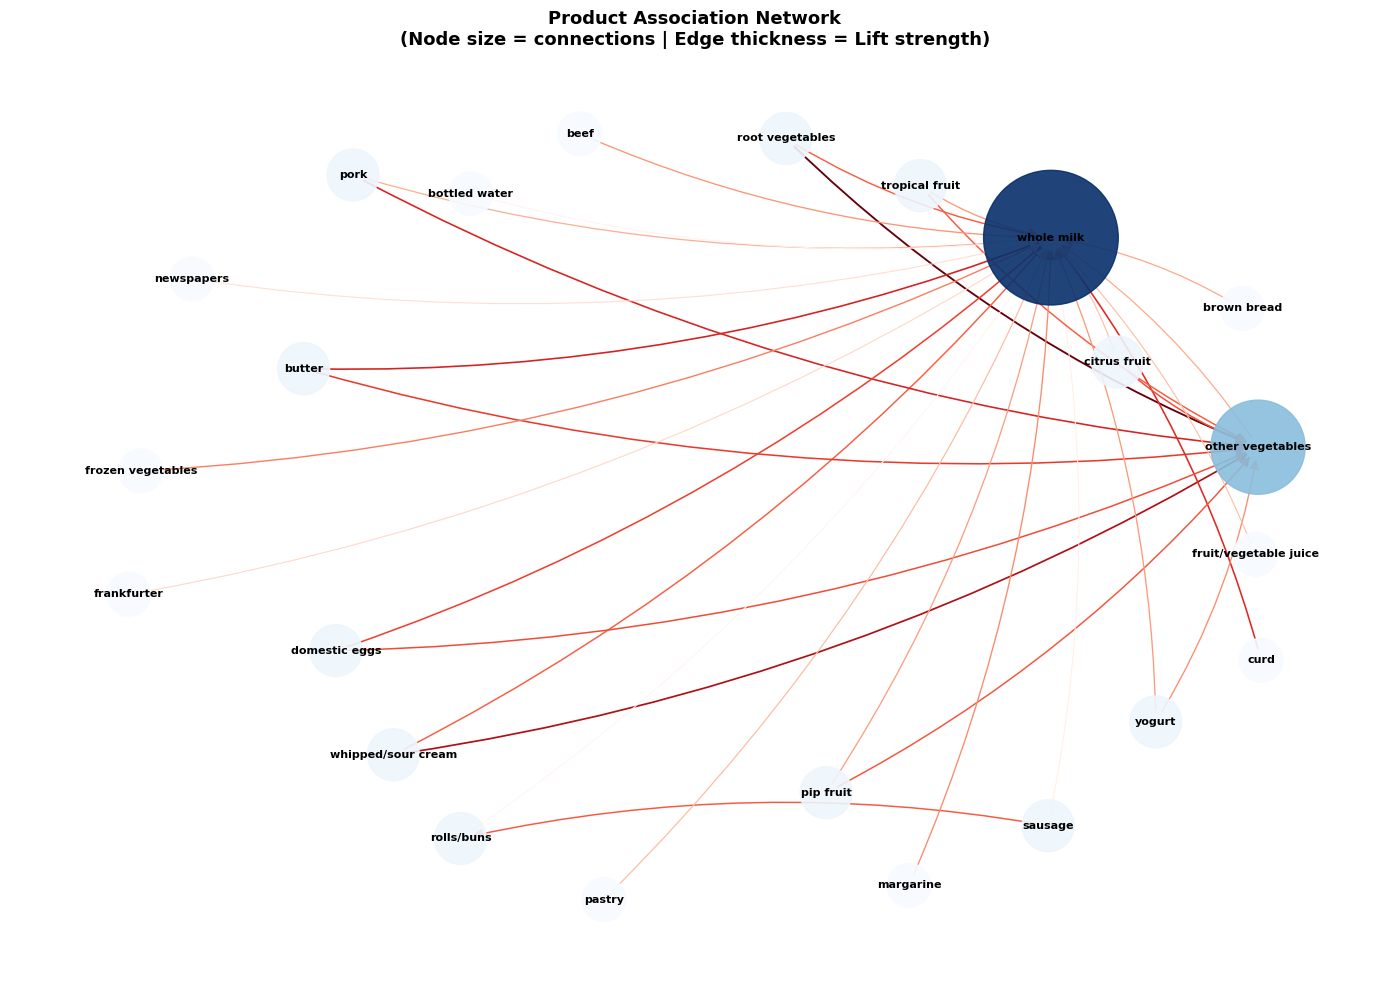


 Network Stats: 23 products | 32 strong associations
 Most connected product: "whole milk" — central hub of buying patterns


In [28]:
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2.5)

# Node size by degree
node_sizes  = [G.degree(n) * 400 + 600 for n in G.nodes()]
node_colors = [G.degree(n) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, cmap=plt.cm.Blues,
                       alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w * 0.6 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.Reds,
                       arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.1', ax=ax)

ax.set_title('Product Association Network\n(Node size = connections | Edge thickness = Lift strength)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Network Stats: {G.number_of_nodes()} products | {G.number_of_edges()} strong associations')

top_node = max(G.degree(), key=lambda x: x[1])

print(f' Most connected product: "{top_node[0]}" — central hub of buying patterns')

## Business Recommendations

In [38]:
# Top Bundle Opportunities
print('=' * 65)
print('        ACTIONABLE BUSINESS RECOMMENDATIONS')
print('=' * 65)


        ACTIONABLE BUSINESS RECOMMENDATIONS


In [41]:
# ── TOP BUNDLE DEALS ──────────────────────────────────────────
print('\n  TOP BUNDLE DEALS TO CREATE:')
print('-' * 65)

top_bundles = rules[rules['confidence'] >= 0.35]\
              .sort_values('lift', ascending=False)\
              .head(8)

for i, (_, row) in enumerate(top_bundles.iterrows(), 1):
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"\n  Bundle #{i}: {ant.upper()}  →→→  {con.upper()}")
    print(f"  ✦ Confidence : {row['confidence']*100:.1f}%")
    print(f"  ✦ Lift       : {row['lift']:.2f}x")
    print(f"  ✦ Meaning    : Every 100 '{ant}' buyers,")
    print(f"                 {row['confidence']*100:.0f} will also buy '{con}'")
    print(f"  {'─' * 55}")



  TOP BUNDLE DEALS TO CREATE:
-----------------------------------------------------------------

  Bundle #1: OTHER VEGETABLES, CITRUS FRUIT  →→→  ROOT VEGETABLES
  ✦ Confidence : 35.9%
  ✦ Lift       : 3.30x
  ✦ Meaning    : Every 100 'other vegetables, citrus fruit' buyers,
                 36 will also buy 'root vegetables'
  ───────────────────────────────────────────────────────

  Bundle #2: ROOT VEGETABLES, CITRUS FRUIT  →→→  OTHER VEGETABLES
  ✦ Confidence : 58.6%
  ✦ Lift       : 3.03x
  ✦ Meaning    : Every 100 'root vegetables, citrus fruit' buyers,
                 59 will also buy 'other vegetables'
  ───────────────────────────────────────────────────────

  Bundle #3: TROPICAL FRUIT, ROOT VEGETABLES  →→→  OTHER VEGETABLES
  ✦ Confidence : 58.5%
  ✦ Lift       : 3.02x
  ✦ Meaning    : Every 100 'tropical fruit, root vegetables' buyers,
                 58 will also buy 'other vegetables'
  ───────────────────────────────────────────────────────

  Bundle #4: CURD, WHOLE 

In [47]:
# Shelf Placement Strategy
print('\n\n SHELF PLACEMENT STRATEGY:')
print('═' * 65)

shelf_rules = rules[
    (rules['lift'] > 1.5) & 
    (rules['support'] > 0.02)
].head(5)

for i, (_, row) in enumerate(shelf_rules.iterrows(), 1):
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"\n  [{i}]  {ant.upper()}  ──shelf──▶  {con.upper()}")
    print(f"       ✦ Lift       :  {row['lift']:.2f}x")
    print(f"       ✦ Support    :  {row['support']*100:.1f}%")
    print(f"       ✦ Confidence :  {row['confidence']*100:.1f}%")
    print(f"       {'─' * 45}")



 SHELF PLACEMENT STRATEGY:
═════════════════════════════════════════════════════════════════

  [1]  ROOT VEGETABLES  ──shelf──▶  OTHER VEGETABLES, WHOLE MILK
       ✦ Lift       :  2.84x
       ✦ Support    :  2.3%
       ✦ Confidence :  21.3%
       ─────────────────────────────────────────────

  [2]  OTHER VEGETABLES, WHOLE MILK  ──shelf──▶  ROOT VEGETABLES
       ✦ Lift       :  2.84x
       ✦ Support    :  2.3%
       ✦ Confidence :  31.0%
       ─────────────────────────────────────────────

  [3]  PIP FRUIT  ──shelf──▶  TROPICAL FRUIT
       ✦ Lift       :  2.57x
       ✦ Support    :  2.0%
       ✦ Confidence :  27.0%
       ─────────────────────────────────────────────

  [4]  TROPICAL FRUIT  ──shelf──▶  PIP FRUIT
       ✦ Lift       :  2.57x
       ✦ Support    :  2.0%
       ✦ Confidence :  19.5%
       ─────────────────────────────────────────────

  [5]  ROOT VEGETABLES, WHOLE MILK  ──shelf──▶  OTHER VEGETABLES
       ✦ Lift       :  2.45x
       ✦ Support    :  2.3%
  

In [50]:
# ── TARGETED PROMOTIONS ───────────────────────────────────────
print('\n\n TARGETED PROMOTION IDEAS:')
print('-' * 65)

promotions = [
    ("Whole Milk buyers",
     "Send coupon for Yogurt or Butter",
     "Highest lift combo in dataset"),

    ("Dairy section",
     "Buy 2 Dairy items → 10% off Vegetables",
     "Strong Dairy + Produce cross-category pattern"),

    ("Breakfast Bundle",
     "Rolls/Buns + Whole Milk combo pack",
     "High support rule — very common purchase"),

    ("Baking Bundle",
     "Butter + Eggs + Baking Powder combo",
     "High confidence baking pattern detected"),
]
for i, (target, offer, reason) in enumerate(promotions, 1):
    print(f"\n  Promotion #{i}:")
    print(f"   Target  :  {target}")
    print(f"   Offer   :  {offer}")
    print(f"   Reason  :  {reason}")
    print(f"  {'─' * 45}")

print('\n' + '═' * 65)
print('    All recommendations are data-driven from')
print('     9,835 real grocery transactions')
print('═' * 65)



 TARGETED PROMOTION IDEAS:
-----------------------------------------------------------------

  Promotion #1:
   Target  :  Whole Milk buyers
   Offer   :  Send coupon for Yogurt or Butter
   Reason  :  Highest lift combo in dataset
  ─────────────────────────────────────────────

  Promotion #2:
   Target  :  Dairy section
   Offer   :  Buy 2 Dairy items → 10% off Vegetables
   Reason  :  Strong Dairy + Produce cross-category pattern
  ─────────────────────────────────────────────

  Promotion #3:
   Target  :  Breakfast Bundle
   Offer   :  Rolls/Buns + Whole Milk combo pack
   Reason  :  High support rule — very common purchase
  ─────────────────────────────────────────────

  Promotion #4:
   Target  :  Baking Bundle
   Offer   :  Butter + Eggs + Baking Powder combo
   Reason  :  High confidence baking pattern detected
  ─────────────────────────────────────────────

═════════════════════════════════════════════════════════════════
    All recommendations are data-driven from
  

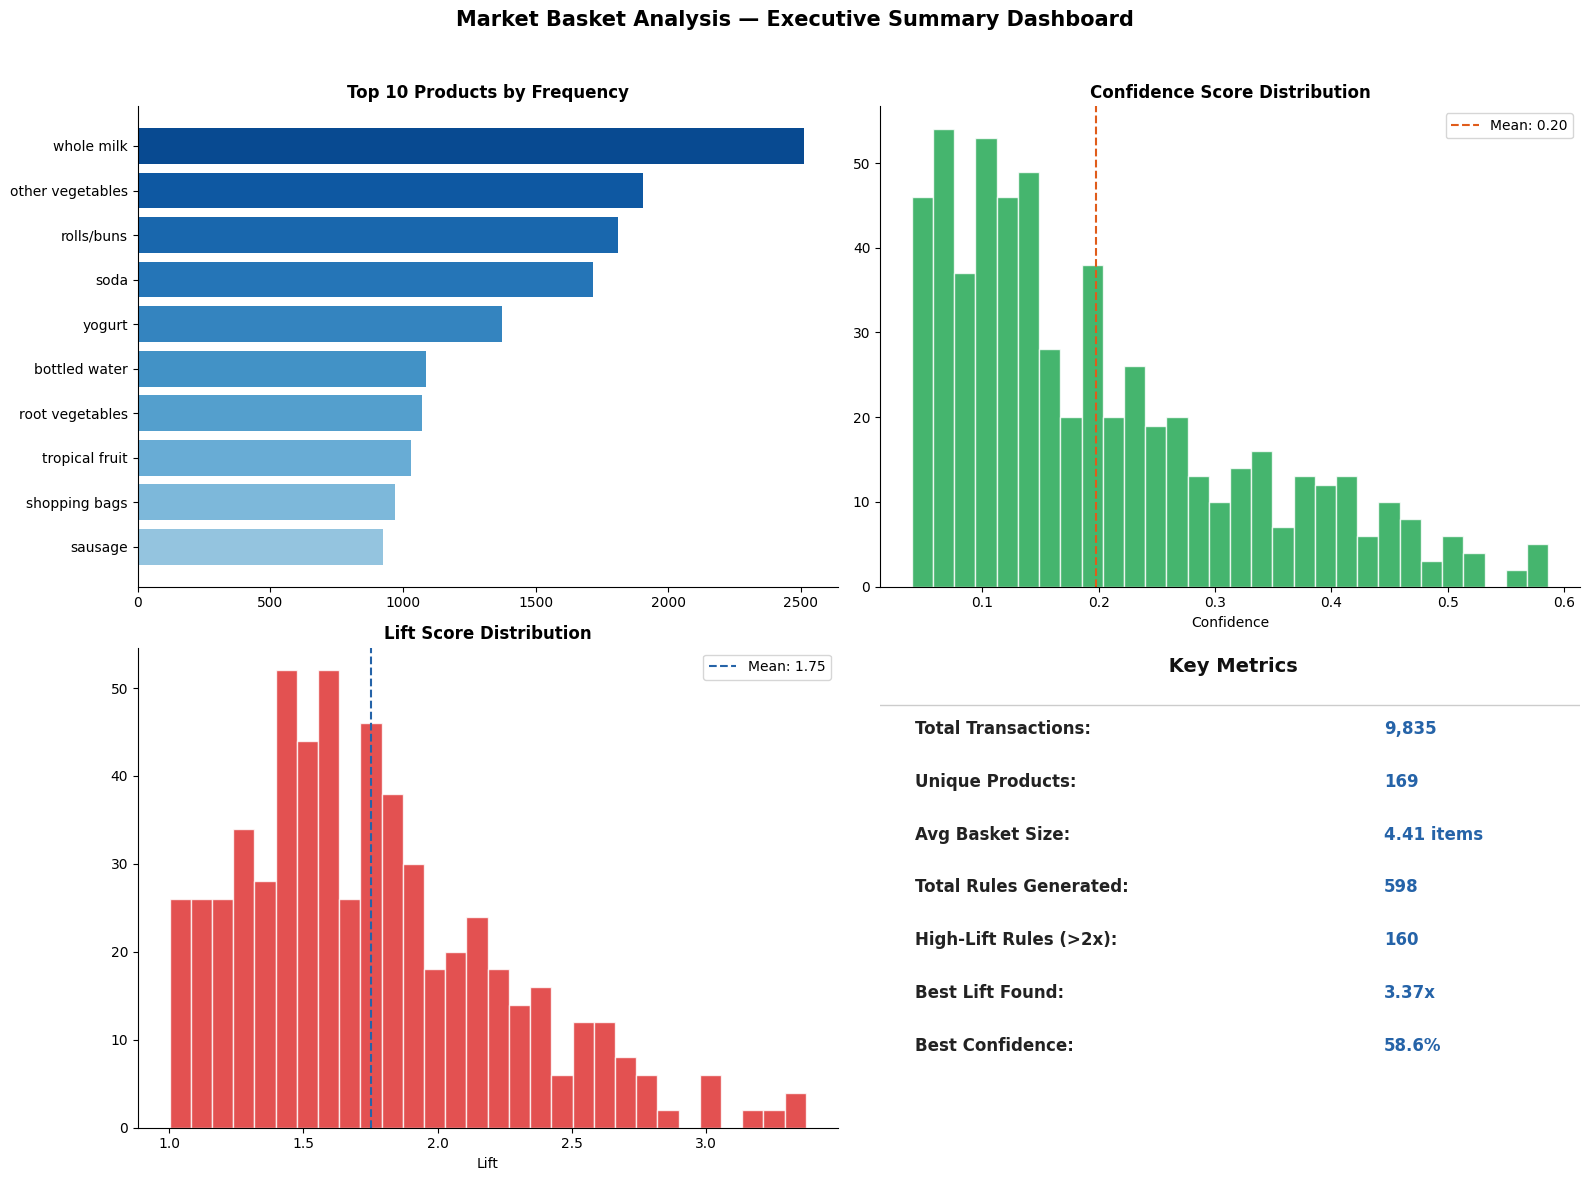

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Market Basket Analysis — Executive Summary Dashboard',
             fontsize=15, fontweight='bold', y=0.98)

# ── Plot 1: Top 10 Products ───────────────────────────────────
top10 = top20.head(10)
axes[0,0].barh(top10['Item'][::-1], top10['Count'][::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, 10)))
axes[0,0].set_title('Top 10 Products by Frequency', 
                     fontweight='bold', fontsize=12)
axes[0,0].spines[['top','right']].set_visible(False)


# ── Plot 2: Confidence Distribution ──────────────────────────
axes[0,1].hist(rules['confidence'], bins=30,
               color=PALETTE[2], edgecolor='white', alpha=0.8)
axes[0,1].axvline(rules['confidence'].mean(), 
                  color=PALETTE[1], linestyle='--',
                  label=f'Mean: {rules["confidence"].mean():.2f}')
axes[0,1].set_title('Confidence Score Distribution', 
                     fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Confidence')
axes[0,1].legend()
axes[0,1].spines[['top','right']].set_visible(False)

# ── Plot 3: Lift Distribution ─────────────────────────────────
axes[1,0].hist(rules['lift'], bins=30,
               color=PALETTE[3], edgecolor='white', alpha=0.8)
axes[1,0].axvline(rules['lift'].mean(), 
                  color=PALETTE[0], linestyle='--',
                  label=f'Mean: {rules["lift"].mean():.2f}')
axes[1,0].set_title('Lift Score Distribution', 
                     fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Lift')
axes[1,0].legend()
axes[1,0].spines[['top','right']].set_visible(False)


# ── Plot 4: KPI Metrics ───────────────────────────────────────
axes[1,1].axis('off')

kpis = [
    ('Total Transactions',    f"{len(groceries):,}"),
    ('Unique Products',       f"{df.shape[1]}"),
    ('Avg Basket Size',       f"{np.mean(basket_sizes):.2f} items"),
    ('Total Rules Generated', f"{len(rules):,}"),
    ('High-Lift Rules (>2x)', f"{len(rules[rules['lift']>2]):,}"),
    ('Best Lift Found',       f"{rules['lift'].max():.2f}x"),
    ('Best Confidence',       f"{rules['confidence'].max()*100:.1f}%"),

]

# Title
axes[1,1].text(0.5, 0.98, ' Key Metrics', 
               ha='center', va='top',
               fontsize=14, fontweight='bold',
               transform=axes[1,1].transAxes,
               color='#111111')

# Divider line
axes[1,1].axhline(y=0.88, color='#cccccc', linewidth=1)

y_pos = 0.82
for label, val in kpis:
    # Label
    axes[1,1].text(0.05, y_pos, f'{label}:',
                   fontsize=12,
                   fontweight='bold',
                   transform=axes[1,1].transAxes,
                   color='#222222')
    # Value
    axes[1,1].text(0.72, y_pos, val,
                   fontsize=12,
                   fontweight='bold',
                   transform=axes[1,1].transAxes,
                   color=PALETTE[0])
    y_pos -= 0.11

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##  Conclusion

### Key Findings:

1. **Whole Milk** is the most dominant product — appearing in **25.5% of all transactions**. Any promotion strategy must consider it as an anchor product.

2. **Yogurt → Whole Milk** is the strongest high-confidence rule — 40% of yogurt buyers also buy whole milk.

3. **Tropical Fruit + Pip Fruit** has the highest lift (2.57x) — these two are bought together 2.57x more than by random chance.

4. **Dairy + Produce** categories show the strongest cross-category associations — ideal for combo offers.

5. Most customers buy **1–5 items per visit** — significant upsell opportunity exists for small-basket customers.

---

### Business Impact:

| Strategy | Based On | Expected Impact |
|---|---|---|
| Bundle: Yogurt + Whole Milk | Lift = 1.57, Conf = 40% | ↑ Avg order value |
| Shelf: Rolls near Whole Milk | Support = 5.6% | ↑ Impulse buys |
| Promo: Dairy + Vegetable combo | Cross-category lift | ↑ Basket size |
| Target: Single-item buyers | 24% of transactions | ↑ Conversion rate |

---

*Analysis by Sumit Sharma | Tools: Python, Pandas, Mlxtend, Seaborn, NetworkX, Matplotlib*
